# **Data Analysis Example - Bitly & MovieLens**

### **13.1 Bitly Data from 1.USA.gov**

### **Thông tin tổng quan**
Bộ dữ liệu 1.USA.gov Bitly được thu thập vào năm 2011 thông qua sự hợp tác giữa dịch vụ rút gọn URL Bitly và trang web chính phủ Mỹ USA.gov.
Khi người dùng truy cập các liên kết rút gọn có đuôi .gov hoặc .mil, hệ thống Bitly sẽ tự động ghi nhận một số thông tin ẩn danh (không chứa dữ liệu cá nhân).

Dữ liệu được lưu dưới dạng tệp văn bản, trong đó mỗi dòng là một đối tượng JSON. Bộ dữ liệu này thường được sử dụng trong các ví dụ phân tích dữ liệu thực hành vì:

- Nó phản ánh hành vi truy cập thực tế của người dùng trên Internet,

- Có cấu trúc đơn giản nhưng đa dạng biến,

- Dễ xử lý bằng Python và các thư viện như pandas, numpy.

### **Ý nghĩa của các biến**
| Tên biến                    | Kiểu dữ liệu      | Ý nghĩa                                                                                                                                                | Ví dụ                                                    |
| --------------------------- | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------- |
| `a` (User-Agent)            | *string*          | Thông tin về trình duyệt và hệ điều hành của người dùng truy cập liên kết. Dữ liệu này giúp phân loại người dùng theo nền tảng (Windows, Mac, Linux…). | `"Mozilla/5.0 (Windows NT 6.1; WOW64)"`                  |
| `tz` (Time Zone)            | *string* / *null* | Múi giờ địa lý mà người dùng truy cập (theo chuẩn IANA). Dữ liệu này hỗ trợ phân tích vị trí địa lý và thời điểm hoạt động.                            | `"America/New_York"`, `"Europe/London"`, `""`, `null`    |
| `r` (Referrer)              | *string*          | URL nguồn mà người dùng click để đến liên kết rút gọn. Giúp xác định kênh giới thiệu.                                                                  | `"http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf"` |
| `u` (Target URL)            | *string*          | URL gốc mà liên kết rút gọn trỏ đến.                                                                                                                   | `"http://www.ncbi.nlm.nih.gov/pubmed/22415991"`          |
| `c` (Country Code)          | *string*          | Mã quốc gia của người truy cập (theo chuẩn ISO).                                                                                                       | `"US"`                                                   |
| `cy` (City)                 | *string*          | Tên thành phố truy cập.                                                                                                                                | `"Danvers"`                                              |
| `gr` (State/Region Code)    | *string*          | Mã tiểu bang hoặc vùng của người dùng.                                                                                                                 | `"MA"`                                                   |
| `ll` (Latitude & Longitude) | *array of float*  | Tọa độ địa lý (vĩ độ, kinh độ) của người dùng truy cập.                                                                                                | `[42.576698, -70.954903]`                                |
| `nk` (Click Count)          | *int*             | Số lượt click vào liên kết.                                                                                                                            | `1`                                                      |
| `t` (Timestamp)             | *int*             | Thời gian truy cập tính theo Unix timestamp.                                                                                                           | `1331923247`                                             |
| `hc` (Hash Created Time)    | *int*             | Thời điểm liên kết được tạo (Unix timestamp).                                                                                                          | `1331822918`                                             |
| `hh` (Short Domain)         | *string*          | Tên miền rút gọn, thường là `1.usa.gov`.                                                                                                               | `"1.usa.gov"`                                            |
| `g` / `h` / `l`             | *string*          | Các mã hash nội bộ Bitly — giúp định danh liên kết.                                                                                                    | `"A6qOVH"`, `"wfLQtf"`, `"orofrog"`                      |


### **Counting Time Zones in Pure Python**

In [2]:
import json
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Đường dẫn tệp Bitly (giữ nguyên theo sách)
path = "C:/Users/Admin/OneDrive/Documents/lab02/dataset/example.txt"

# 1. Đọc và phân tích dữ liệu JSON
records = [json.loads(line) for line in open(path, encoding='utf-8')]

# 2. Trích xuất múi giờ (chỉ bao gồm các bản ghi có trường 'tz')
time_zones = [rec["tz"] if "tz" in rec and rec["tz"] is not None else "(Không xác định)" for rec in records]

# 3. Hàm đếm thủ công (get_counts)
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

# 4. Hàm sắp xếp và in ra kết quả top N (top_counts)
def top_counts(count_dict, n=10):
    # Chuyển từ điển sang danh sách các cặp (số lượng, múi giờ)
    value_key_pairs = [(count, tz) for tz, count in count_dict.items()]
    # Sắp xếp theo số lượng giảm dần
    value_key_pairs.sort(key=lambda x: x[0], reverse=True)
    return value_key_pairs[:n]

counts = get_counts(time_zones)
top_results = top_counts(counts)

print("--- 13.1.1 Đếm Múi giờ bằng Pure Python ---")
print("Top 10 múi giờ (Bao gồm chuỗi rỗng và NaN nếu có):")
for count, tz in top_results:
    tz_display = "(Không xác định)" if tz == "" else str(tz)
    print(f"- {tz_display}: {count}")

--- 13.1.1 Đếm Múi giờ bằng Pure Python ---
Top 10 múi giờ (Bao gồm chuỗi rỗng và NaN nếu có):
- America/New_York: 3
- (Không xác định): 2
- America/Chicago: 2
- America/Denver: 1
- America/Los_Angeles: 1
- Europe/London: 1
- (Không xác định): 1


#### Nhận xét
- America/New_York đứng đầu với 3 lượt truy cập, chọn quan tâm lớn đến nội dung từ khu vực này.

- Các múi giờ khác như America/Chicago và America/Denver có số lượt truy cập thấp hơn, nhưng vẫn đáng chú ý.

- Hai mục được liệt kê là "(Không xác định)", với tổng cộng 3 lượt truy cập. Điều này chỉ ra rằng có một số người dùng không thể phân loại theo múi giờ, làm giảm tính chính xác của phân tích.

### **Biểu đồ TOP 10 MÚI GIỜ** 

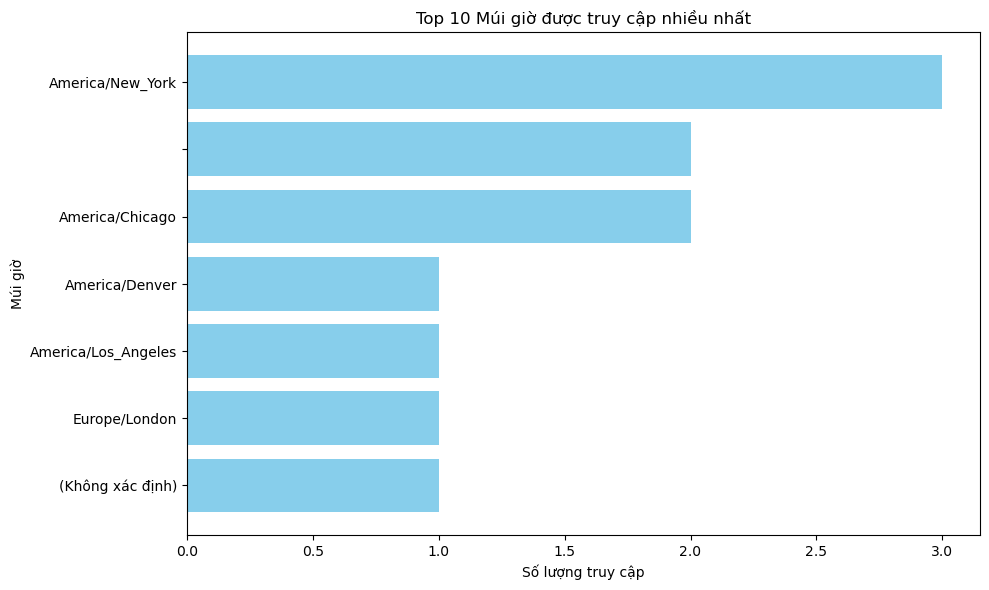

In [3]:
# ----------- VẼ BIỂU ĐỒ TOP 10 MÚI GIỜ -----------
plt.figure(figsize=(10,6))
tz_labels = [tz for count, tz in top_results]
tz_values = [count for count, tz in top_results]
plt.barh(tz_labels, tz_values, color='skyblue')
plt.xlabel("Số lượng truy cập")
plt.ylabel("Múi giờ")
plt.title("Top 10 Múi giờ được truy cập nhiều nhất")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Nhận xét
- Biểu đồ có thể hiển thị số lượng truy cập từ các múi giờ khác nhau, cho phép người xem bắt được ở khu vực có tốc độ truy cập cao nhất.

- Đầu giờ America/New_York , đã tìm thấy tập trung lớn vào nội dung từ khu vực này, có thể liên kết đến các trang web hoặc dịch vụ phổ biến.

- Các múi giờ khác như America/Chicago và America/Los_Angeles cũng đóng góp lời khuyên vào tổng số lượt truy cập, chọn đa dạng trong địa chỉ nguồn gốc của người dùng.

- Sự xuất hiện của thanh cho các bản ghi không được xác định cho thấy một lượng truy cập chưa được phân loại rõ ràng, điều này cần được lưu ý trong phân tích để cải thiện độ chính xác.


### **Counting Time Zones with pandas**

In [4]:
import pandas as pd
import json
import numpy as np
import os

# Đường dẫn tệp Bitly
path = "C:/Users/Admin/OneDrive/Documents/lab02/dataset/example.txt"
records = [json.loads(line) for line in open(path, encoding='utf-8')]

print("\n--- 13.1.2 Đếm Múi giờ với pandas ---")

# 1. Tạo DataFrame và Đếm tần suất
frame = pd.DataFrame(records)
tz_counts_pandas = frame['tz'].value_counts()

print("Top 5 múi giờ (Sử dụng value_counts của pandas):")
print(tz_counts_pandas.head())

# 2. Làm sạch dữ liệu và phân tích OS (Trang 430-434)
# Thay thế giá trị thiếu (NaN) bằng 'Missing' và chuỗi rỗng ('') bằng 'Unknown'
clean_tz = frame['tz'].fillna('Missing').replace('', 'Unknown')

# Lọc các bản ghi có chuỗi tác nhân người dùng 'a' không null
cframe = frame[frame.a.notnull()].copy()

# Tạo cột 'os' để phân loại Hệ điều hành (Windows vs Not Windows)
cframe['os'] = np.where(cframe['a'].str.contains('Windows'), 'Windows', 'Not Windows')
cframe['tz'] = clean_tz[cframe.index] # Gán cột tz đã làm sạch

# 3. Tạo bảng tổng hợp số lượng theo Múi giờ và OS
by_tz_os = cframe.groupby(['tz', 'os']).size().unstack(fill_value=0)
subset = by_tz_os.sum(1).sort_values(ascending=False)
top_tz = subset.head(10).index
top_by_tz_os = by_tz_os.loc[top_tz]

print("\nBảng tổng hợp theo Múi giờ và Hệ điều hành (Top 5):")
print(by_tz_os.loc[subset.head(5).index])


--- 13.1.2 Đếm Múi giờ với pandas ---
Top 5 múi giờ (Sử dụng value_counts của pandas):
tz
America/New_York       3
                       2
America/Chicago        2
America/Denver         1
America/Los_Angeles    1
Name: count, dtype: int64

Bảng tổng hợp theo Múi giờ và Hệ điều hành (Top 5):
os                   Not Windows  Windows
tz                                       
America/New_York               1        2
Unknown                        0        2
America/Chicago                0        2
America/Los_Angeles            1        0
America/Denver                 1        0


#### Nhận xét
- America/New_York vẫn dẫn đầu với 3 lượt truy cập, cho thấy tính chất nhất quán trong quan tâm đến múi giờ này.

- Có một giá trị không được xác định (chuỗi rỗng) với 2 lượt truy cập, điều này cần được chú ý vì nó có thể gây nhầm lẫn trong phân tích.

- Việc không xác định giá trị trong danh sách là một vấn đề, cho thấy rằng một số bản ghi không được phân loại rõ ràng, cần được xử lý để cải thiện tính chính xác.

- Bảng tổng hợp đã tìm thấy phân tích của các hệ điều hành theo múi giờ, với America/New_York có 2 lượt truy cập từ Windows, điều này có thể phản ánh rằng người dùng từ khu vực này thường sử dụng hệ điều hành Windows.

- Không xác định (không xác định) có 2 lượt xem từ Windows, cho thấy rằng có một số người dùng không được phân loại đúng, điều này có thể ảnh hưởng đến hoạt động phân tích hành động của người dùng.

### **Biểu đồ Phân bố Hệ điều hành theo Múi giờ (Top 10)**

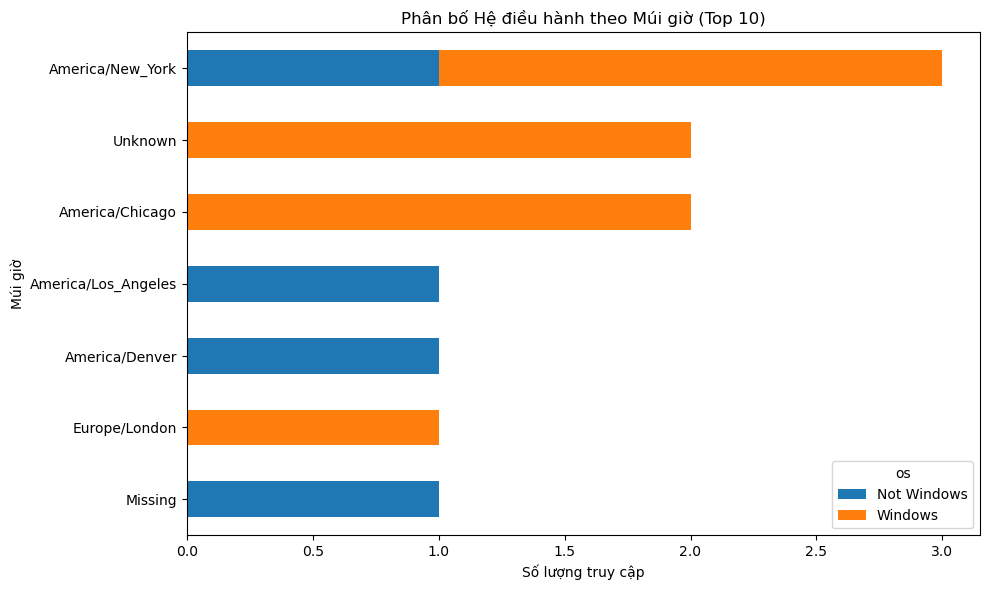

In [5]:
top_by_tz_os.plot(kind='barh', stacked=True, figsize=(10,6), color=['#1f77b4','#ff7f0e'])
plt.xlabel("Số lượng truy cập")
plt.ylabel("Múi giờ")
plt.title("Phân bố Hệ điều hành theo Múi giờ (Top 10)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Nhận xét
- Biểu đồ cho thấy sự phân bố của các hệ điều hành (Windows và Not Windows) theo từng múi giờ, giúp người xem dễ dàng nhận biết sự khác biệt trong cách sử dụng hệ điều hành.

- America/New_York dẫn đầu với số lượng truy cập cao từ cả hai hệ điều hành, cho thấy sự quan tâm lớn đến nội dung trong khu vực này.

- Không rõ số lượng truy cập từ Windows, cho thấy có nhiều người dùng không thể phân loại rõ ràng.

- Thanh "Missing" có thể đại diện cho các bản ghi không có dữ liệu rõ ràng về múi giờ hoặc hệ điều hành. Điều này cần được chú ý vì nó có thể gây nhầm lẫn trong phân tích.

### **2. MovieLens 1M Dataset**

### **Thông tin tổng quan**
MovieLens 1M là một bộ dữ liệu chuẩn mực ổn định (stable benchmark dataset) thường được sử dụng trong nghiên cứu về hệ thống gợi (recommendation systems) và khai phá dữ liệu.

Nguồn gốc: Được thu thập bởi nhóm nghiên cứu GroupLens tại Đại học Minnesota, Mỹ.

Quy mô: Chứa hơn 1 triệu đánh giá (rating) từ 6.040 người dùng về 3.900 bộ phim.

Mục đích: Nghiên cứu và phát triển các thuật toán gợi ý phim, phân tích hành vi và sở thích của người dùng, đặc biệt là sự khác biệt trong đánh giá giữa các nhóm người dùng khác nhau (như Giới tính).

Bộ dữ liệu được chia thành ba tệp chính, được liên kết với nhau bằng các ID chung (user_id và movie_id):
| **Tệp dữ liệu** | **Nội dung chính**                                                                                                      | **Biến liên kết**     |
| --------------- | ----------------------------------------------------------------------------------------------------------------------- | --------------------- |
| `ratings.dat`   | Chứa 1 triệu bản ghi về điểm đánh giá (rating) và thời điểm đánh giá (timestamp).                                       | `user_id`, `movie_id` |
| `users.dat`     | Chứa thông tin nhân khẩu học của 6.040 người dùng, bao gồm gender (giới tính), age (tuổi), và occupation (nghề nghiệp). | `user_id`             |
| `movies.dat`    | Chứa thông tin về 3.900 bộ phim, bao gồm title (tiêu đề) và genres (thể loại).                                          | `movie_id`            |


### **Ý nghĩa của các biến**

**users.dat**
| **Tên biến** | **Ý nghĩa**   | **Giá trị**                                                                                                  |
| ------------ | ------------- | ------------------------------------------------------------------------------------------------------------ |
| `user_id`    | Mã Người dùng | Mã định danh duy nhất cho mỗi người dùng                                                                     |
| `gender`     | Giới tính     | `'F'` (Nữ) hoặc `'M'` (Nam)                                                                                  |
| `age`        | Tuổi          | Được mã hóa thành các nhóm tuổi (ví dụ: `1`: Under 18, `25`: 25–34, `56`: 56+)                               |
| `occupation` | Nghề nghiệp   | Mã số đại diện cho 21 loại nghề nghiệp khác nhau (ví dụ: `0`: other, `1`: academic/educator, `4`: artist, …) |
| `zip`        | Zip-code      | Mã bưu chính của người dùng (ít được sử dụng trong phân tích cơ bản)                                         |

**ratings.dat**
| **Tên biến** | **Ý nghĩa**   | **Giá trị**                                                                                               |
| ------------ | ------------- | --------------------------------------------------------------------------------------------------------- |
| `user_id`    | Mã Người dùng | Liên kết với tệp `users.dat`                                                                              |
| `movie_id`   | Mã Phim       | Liên kết với tệp `movies.dat`                                                                             |
| `rating`     | Điểm Đánh giá | Điểm số từ `1` (thấp nhất) đến `5` (cao nhất). Đây là biến đo lường chính để phân tích sự không đồng tình |
| `timestamp`  | Dấu thời gian | Thời gian đánh giá được tạo, lưu dưới dạng số giây từ Epoch (Unix time)                                   |

**movies.dat**
| **Tên biến** | **Ý nghĩa**  | **Ghi chú**                                                              |     |
| ------------ | ------------ | ------------------------------------------------------------------------ | --- |
| `movie_id`   | Mã Phim      | Mã định danh duy nhất cho mỗi bộ phim.                                   |     |
| `title`      | Tiêu đề Phim | Tên đầy đủ của bộ phim, thường bao gồm năm phát hành.                    |     |
| `genres`     | Thể loại     | Một chuỗi chứa nhiều thể loại phim, được phân tách bằng dấu gạch đứng (` | `). |


### **2.1 Measuring Rating Disagreement**

In [6]:
import pandas as pd
import numpy as np
import os

print("\n--- 13.2 MovieLens 1M Dataset: Đo lường Sự không đồng tình ---")

# Đường dẫn đến các tệp dữ liệu MovieLens 1M
data_dir = "C:/Users/Admin/OneDrive/Documents/lab02/dataset/ml-1m/ml-1m/"
# Định nghĩa tên cột và đọc tệp (giữ nguyên theo sách)
unames = ['user_id', 'gender', 'age', 'occupation', 'zip']
rnames = ['user_id', 'movie_id', 'rating', 'timestamp']
mnames = ['movie_id', 'title', 'genres']

# Đọc tệp, sử dụng '::' làm dấu phân cách
users = pd.read_table(os.path.join(data_dir + "users.dat"), sep="::", header=None, names=unames, engine='python')
ratings = pd.read_table(os.path.join(data_dir + "ratings.dat"), sep="::", header=None, names=rnames, engine='python')
movies = pd.read_table(os.path.join(data_dir + "movies.dat"), sep="::", header=None, names=mnames, engine='python', encoding='latin-1')


# 1. Hợp nhất (Merge) các DataFrame
data = pd.merge(pd.merge(ratings, users), movies)

print("DataFrame hợp nhất (5 dòng đầu):")
print(data.head())


# 2. Tính điểm trung bình theo Tiêu đề và Giới tính
# Sử dụng pivot_table để tính giá trị trung bình ('rating')
mean_ratings = data.pivot_table('rating', index='title', columns='gender')

# 3. Đo lường sự không đồng tình: Tính độ lệch (Nam - Nữ)
# Chỉ xét các phim có đánh giá từ cả hai giới tính (loại bỏ NaN)
mean_ratings = mean_ratings.dropna()
mean_ratings['diff'] = mean_ratings['M'] - mean_ratings['F']

# 4. Sắp xếp để tìm ra phim có độ lệch lớn nhất

# Phim được NAM đánh giá cao hơn NHIỀU (diff dương lớn nhất)
sorted_M_higher = mean_ratings.sort_values(by='diff', ascending=False)
print("\nTop 5 Phim được NAM đánh giá cao hơn NỮ:")
print(sorted_M_higher[['M', 'F', 'diff']].head())

# Phim được NỮ đánh giá cao hơn NHIỀU (diff âm lớn nhất)
sorted_F_higher = mean_ratings.sort_values(by='diff', ascending=True)
print("\nTop 5 Phim được NỮ đánh giá cao hơn NAM:")
print(sorted_F_higher[['M', 'F', 'diff']].head())

top_diff_movies = sorted_M_higher.head(10)


--- 13.2 MovieLens 1M Dataset: Đo lường Sự không đồng tình ---
DataFrame hợp nhất (5 dòng đầu):
   user_id  movie_id  rating  timestamp gender  age  occupation    zip  \
0        1      1193       5  978300760      F    1          10  48067   
1        1       661       3  978302109      F    1          10  48067   
2        1       914       3  978301968      F    1          10  48067   
3        1      3408       4  978300275      F    1          10  48067   
4        1      2355       5  978824291      F    1          10  48067   

                                    title                        genres  
0  One Flew Over the Cuckoo's Nest (1975)                         Drama  
1        James and the Giant Peach (1996)  Animation|Children's|Musical  
2                     My Fair Lady (1964)               Musical|Romance  
3                  Erin Brockovich (2000)                         Drama  
4                    Bug's Life, A (1998)   Animation|Children's|Comedy  

Top 5 Phim đư

#### Nhận xét
- Bảng tổng hợp các bộ phim được đánh giá cao hơn nam giới (NAM) so với nữ giới (NỮ). Các bộ phim như Tigrero: A Film That Was Never Made (1994) và Neon Bible, The (1995) có sự chênh lệch đáng kể ở điểm giữa hai giới.

- Các phim có sự chênh lệch lớn giữa số lượng nam và nữ cho thấy sự khác biệt trong sở thích và quan điểm về phim của hai nhóm này. Điều này có thể cung cấp thông tin quý báu cho các nhà làm phim và nhà phân tích thị trường.

### **Top 10 Phim được Nam đánh giá cao hơn Nữ**

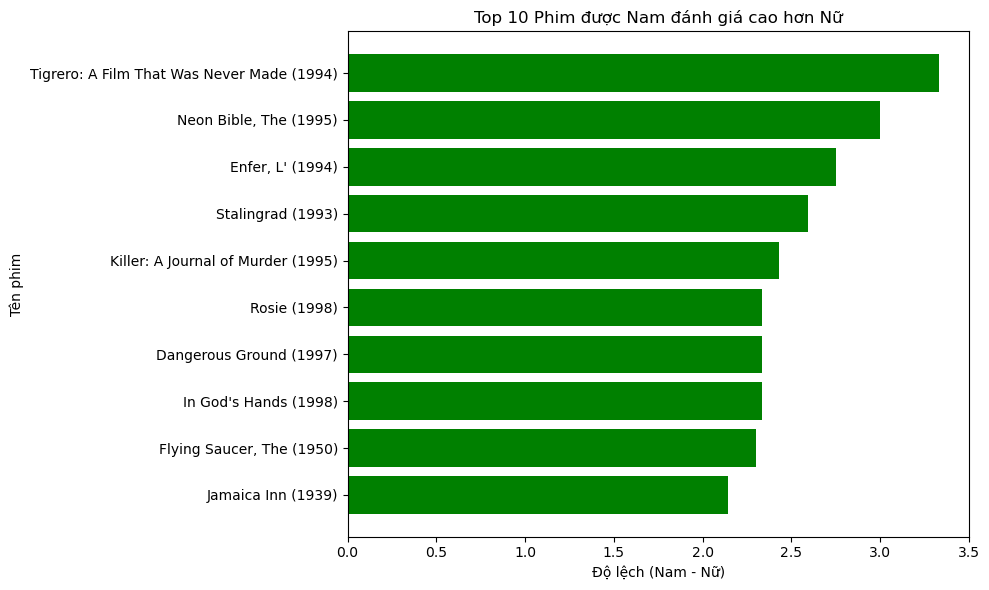

In [7]:
plt.figure(figsize=(10,6))
plt.barh(top_diff_movies.index, top_diff_movies['diff'], color='green')
plt.xlabel("Độ lệch (Nam - Nữ)")
plt.ylabel("Tên phim")
plt.title("Top 10 Phim được Nam đánh giá cao hơn Nữ")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(top_diff_movies.index, top_diff_movies['diff'], color='green')
plt.xlabel("Độ lệch (Nam - Nữ)")
plt.ylabel("Tên phim")
plt.title("Top 10 Phim được Nam đánh giá cao hơn Nữ")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Nhận xét
- Biểu đồ có thể hiển thị rõ ràng sự chênh lệch đánh giá giữa nam và nữ cho từng bộ phim, giúp người xem dễ dàng nhận biết các bộ phim mà nam giới đánh giá cao hơn.

- Tigrero: A Film That Was Never Made (1994) đứng đầu danh sách với độ chênh lệch lớn nhất, cho thấy sự mạnh mẽ của nam giới đối với bộ phim này.

- Các bộ phim khác như Neon Bible, The (1995) và Stalingrad (1993) cũng có chênh lệch đáng kể, cho thấy sự khác biệt đặc biệt trong sở thích giữa hai giới.